In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import datetime
import autokeras as ak
import seaborn as sns
import glob
from PIL import Image
from sklearn.utils import shuffle
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_curve, classification_report

In [ ]:
def img_process(img):
    img = Image.open(img)
    img = img.convert('RGB')
    img = img.resize((256, 256))
    img = np.asarray(img) / 255.0
    return img

class AutoImageClassification:
    def __init__(self, path):
        self.train_df = self._create_df(path, '학습')
        self.test_df  = self._create_df(path, '테스트')

    @staticmethod
    def _create_df(path, path2):
        files1 = glob.glob(path + "/" + path2 + "/정상/*.png")
        files2 = glob.glob(path + "/" + path2 + "/불량/*.png")

        print('정상: ', len(files1))
        print('불량: ', len(files2))

        df_n = pd.DataFrame()
        df_p = pd.DataFrame()

        df_n['name'] = [x for x in files1]
        df_n['outcome'] = 0

        df_p['name'] = [x for x in files2]
        df_p['outcome'] = 1

        df = pd.concat([df_n, df_p], axis=0, ignore_index=True)
        df = shuffle(df, random_state=42).reset_index(drop=True)
        return df

    def create_xand_y(self):
        x = np.array([img_process(p) for p in self.train_df['name'].values], dtype=np.float32)
        y = self.train_df['outcome'].values.astype(np.int64)
        return x, y
dir_path =r'/content/drive/MyDrive/제조이미지 데이터'
aic = AutoImageClassification(path =dir_path)

정상:  1102
불량:  59
정상:  276
불량:  15


In [ ]:
project_directory = "/content/drive/MyDrive/autokeras_models"
X, y = aic.create_xand_y()
model = ak.ImageClassifier(max_trials=1, loss='binary_crossentropy',
metrics ='accuracy',overwrite=True,directory=project_directory)
model.fit(x=X,y=y,epochs=3,validation_split=0.2,verbose=2)
model = model.export_model()

Trial 1 Complete [00h 09m 41s]
val_loss: 0.005711924284696579

Best val_loss So Far: 0.005711924284696579
Total elapsed time: 00h 09m 41s
Epoch 1/3
37/37 - 193s - 5s/step - accuracy: 0.9526 - loss: 0.7099
Epoch 2/3
37/37 - 197s - 5s/step - accuracy: 0.9931 - loss: 0.0201
Epoch 3/3
37/37 - 190s - 5s/step - accuracy: 1.0000 - loss: 0.0014


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
x_test =np.array([img_preprocess(p)for p in aic.test_df.name.values])
y_test= aic.test_df.outcome.values

In [ ]:
y_pred_ori = model.predict(x_test)
y_pred =[round(y[0],0)for y in y_pred_ori]
print("accuracy =  ",accuracy_score(y_test,y_pred))
print("recall= ",recall_score(y_test,y_pred))
print("precision = ",precision_score(y_test,y_pred))
print("f1 score= ", f1_score(y_test,y_pred))

10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step
accuracy =   1.0
recall=  1.0
precision =  1.0
f1 score=  1.0


(array([276.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,  14.]),
 array([7.24548363e-06, 1.00005142e-01, 2.00003043e-01, 3.00000936e-01,
        3.99998844e-01, 4.99996752e-01, 5.99994659e-01, 6.99992597e-01,
        7.99990475e-01, 8.99988353e-01, 9.99986291e-01]),
 <BarContainer object of 10 artists>)

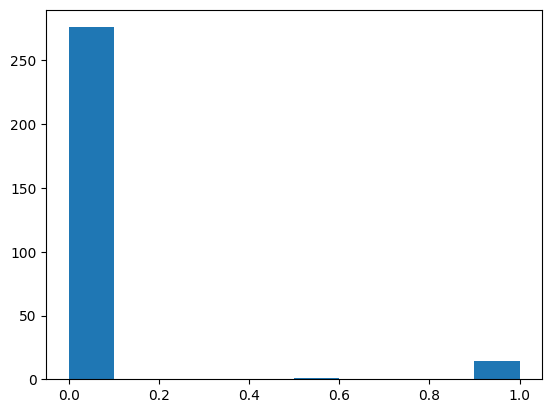

In [ ]:
plt.hist(y_pred_ori)

In [ ]:
print('AutoKeras Model Predict: ', y_pred)
rmse= sqrt(mean_squared_error(y_test,y_pred))
print('AutoKeras Model RMS: ',rmse)

AutoKeras Model Predict:  [np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(1.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(1.0), np.float32(0.0), np.float32(0.0), np.float32(1.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(1.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(1.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.f

In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred, labels=[1,0])
print(conf_matrix)

[[ 15   0]
 [  0 276]]


In [ ]:
fpr,tpr,thresholds = roc_curve(y_test,y_pred)
print(fpr,tpr,thresholds)

[0. 0. 1.] [0. 1. 1.] [inf  1.  0.]


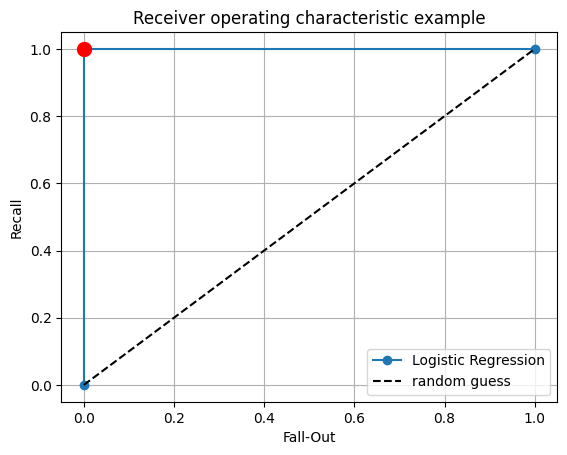

In [ ]:
recall = conf_matrix[0][0]/(conf_matrix[0][0]+conf_matrix[0][1])
fallout = conf_matrix[1][0]/(conf_matrix[1][0]+conf_matrix[1][1])
plt.plot(fpr,tpr,'o-',label="Logistic Regression")
plt.plot([0,1],[0,1],'k--',label="random guess")
plt.plot([fallout],[recall],'ro',ms=10)
plt.xlabel('Fall-Out')
plt.ylabel('Recall')
plt.title('Receiver operating characteristic example')
plt.grid()
plt.legend()
plt.show()

In [ ]:
print(classification_report(y_test,y_pred,target_names=['class 0','class 1']))

              precision    recall  f1-score   support

     class 0       1.00      1.00      1.00       276
     class 1       1.00      1.00      1.00        15

    accuracy                           1.00       291
   macro avg       1.00      1.00      1.00       291
weighted avg       1.00      1.00      1.00       291

